## Customer Intelligence Platform: Churn Prediction, Segmentation & Lifetime Value Forecasting

In [1]:
# Using python to build the dataset for Customer Intelligence Platform

In [2]:
# Importing Libraries

import numpy as np
import pandas as pd

### Simulating Customer table

In [3]:
np.random.seed(21)
# storing the randomely generated customer data in seed 21

n_customers = 1000
# creating 1000 fake customers

customers = pd.DataFrame({
                'customer_id'         : range(1, n_customers + 1),
                                        # range(start,end) assigns unique id from 1 to 1000 for each customer
    
                'signup_date'         : pd.to_datetime(
                                        np.random.choice(pd.date_range('2022-01-01', '2024-12-31'), n_customers)
                                        ),
                                        # np.random.choice(x,y) randomely generates y values in x range
                                        # here 1000 values gets generated in range set by pd.date_range(start,end)
                                        # finally pd.to_datetime converts values into Pandas datetime format
    
                'region'              : np.random.choice(['London','Manchester','Birmingham','Leeds'], n_customers),
                                        # randomely generates 1000 values of region names
    
                'acquisition_channel' : np.random.choice(['Google Ads','Organic','Instagram','Referral'], n_customers)
                                        # randomely generates 1000 values of acquisition channels
                        })

In [4]:
# Display of customers table

customers.tail()

,customer_id,signup_date,region,acquisition_channel
995,996,2022-05-11,London,Referral
996,997,2022-07-12,Leeds,Instagram
997,998,2024-06-13,Leeds,Organic
998,999,2024-05-30,Birmingham,Google Ads
999,1000,2024-11-21,Birmingham,Instagram


### Simulating Products table

In [5]:
n_products = 50
# creating 50 fake products

products = pd.DataFrame({
                'product_id' : range(1, n_products + 1),
                               # range(start,end) assigns unique id from 1 to 50 for each product
    
                'category'   : np.random.choice(['Skincare','Makeup','Haircare','Fragrance'], n_products),
                               # randomely generates 50 values of product categories
    
                'cost_price' : np.random.uniform(5, 30, n_products)
                               # randomely generates 50 decimals values in range of 5 and 30
                        })

In [6]:
# Display of products table

products.tail()

,product_id,category,cost_price
45,46,Fragrance,15.908884
46,47,Fragrance,22.949608
47,48,Skincare,16.789549
48,49,Fragrance,25.096019
49,50,Fragrance,24.454894


### Simulating Transactions table

In [7]:
n_transactions = 10000
# creating 10000 fake transactions

transactions = pd.DataFrame({
                    'transaction_id'    : range(1, n_transactions + 1),
                                          # range(start,end) assigns unique id from 1 to 10000 for each transaction
    
                    'customer_id'       : np.random.randint(1, n_transactions + 1, n_transactions),
                                          # randomely generates 10000 customer_id in range 1 to 10000
    
                    'product_id'        : np.random.randint(1, n_products + 1, n_transactions),
                                          # randomely generates 10000 product_id in range of 1 to 10000
    
                    'transaction_date'  : pd.to_datetime(
                                          np.random.choice(pd.date_range('2022-01-01', '2024-12-31'), n_transactions)
                                          ),
                                          # here 10000 values gets generated in range set by pd.date_range(start,end)
                                          # finally pd.to_datetime converts values into Pandas datetime format
    
                    'quantity'          : np.random.randint(1, 5, n_transactions)
                                          # randomely generates 10000 quantities in range of 1 to 5
                            })

In [8]:
# Display of transactions table

transactions.tail()

,transaction_id,customer_id,product_id,transaction_date,quantity
9995,9996,8845,17,2023-06-25,1
9996,9997,39,9,2023-06-23,3
9997,9998,3325,10,2022-08-01,1
9998,9999,8426,48,2022-08-25,1
9999,10000,8358,33,2023-05-01,2


### Adding Pricing Logic

In [9]:
# Merging products table with transactions table using product_id as common/primary key

transactions = transactions.merge(products[['product_id', 'cost_price']], on = 'product_id')

# only selecing product_id and cost_price columns from products table

transactions.head()

,transaction_id,customer_id,product_id,transaction_date,quantity,cost_price
0,1,3296,19,2023-04-20,2,8.982944
1,2,8781,12,2022-01-30,3,10.599371
2,3,3512,38,2024-02-18,1,6.218637
3,4,4411,29,2024-03-13,1,14.021917
4,5,7083,25,2023-01-22,3,8.368087


In [10]:
# Generating Selling Price
np.random.seed(21)

transactions['selling_price'] = transactions['cost_price'] * np.random.uniform(1.2, 2.5, len(transactions))

# np.random.uniform generates 10000 values in range of 1.2 to 2.5
# here 1.2 to 2.5 is price mark up for selling price (20% to 150%)
# this generates 10000 values which gets assigned to new column 'selling_price'

transactions.tail()

,transaction_id,customer_id,product_id,transaction_date,quantity,cost_price,selling_price
9995,9996,8845,17,2023-06-25,1,27.300450,40.394758
9996,9997,39,9,2023-06-23,3,8.101353,16.422462
9997,9998,3325,10,2022-08-01,1,16.362263,26.089415
9998,9999,8426,48,2022-08-25,1,16.789549,32.646208
9999,10000,8358,33,2023-05-01,2,24.394149,50.734795


In [11]:
# Generating Revenue

transactions['revenue'] = transactions['selling_price'] * transactions['quantity']

transactions.tail()

,transaction_id,customer_id,product_id,transaction_date,quantity,cost_price,selling_price,revenue
9995,9996,8845,17,2023-06-25,1,27.300450,40.394758,40.394758
9996,9997,39,9,2023-06-23,3,8.101353,16.422462,49.267385
9997,9998,3325,10,2022-08-01,1,16.362263,26.089415,26.089415
9998,9999,8426,48,2022-08-25,1,16.789549,32.646208,32.646208
9999,10000,8358,33,2023-05-01,2,24.394149,50.734795,101.469591


In [12]:
# Removing Cost Price column from transactions table for cleanup

transactions = transactions.drop('cost_price',  axis = 1)

transactions.head()

,transaction_id,customer_id,product_id,transaction_date,quantity,selling_price,revenue
0,1,3296,19,2023-04-20,2,11.348533,22.697066
1,2,8781,12,2022-01-30,3,16.702940,50.108819
2,3,3512,38,2024-02-18,1,13.290820,13.290820
3,4,4411,29,2024-03-13,1,17.220332,17.220332
4,5,7083,25,2023-01-22,3,12.281838,36.845515


### Transporting data items from python to dataframe to run SQL queries

In [13]:
# Importing libraries

import sqlite3 as sql
import pandas as pd

In [14]:
# Crearting a File Connection with customer_data file

file_conn = sql.connect('customer_data')

In [15]:
# Inserting the data items from pandas into dataframe

customers.to_sql('dim_customers', file_conn, if_exists = 'append', index = False)

products.to_sql('dim_products', file_conn, if_exists = 'append', index = False)

transactions.to_sql('fact_transactions', file_conn, if_exists = 'append', index = False)

#### Importing dataframe from SQL

In [16]:
# Importing library and SQLite dataframe

import sqlite3 as sql
import pandas as pd

In [17]:
# Running the SQlite queries from DBeaver inside the python

customer_lifetime_metrics = '''
SELECT		customer_id AS [Customer_ID],
			MIN(DATE(transaction_date)) AS [First_Purchase_Date],
			MAX(DATE(transaction_date)) AS [Last_Purchase_Date],
			COUNT(transaction_id) AS [Total_Orders],
			ROUND(SUM(revenue),2) AS [Total_Revenue]
			-- customer_id grouped, iterations performed on rest columns
FROM 		fact_transactions ft 
GROUP BY	customer_id
ORDER BY	customer_id ASC;
'''

recency_frequency_monetary = '''
SELECT		customer_id AS [Customer_ID],
			CAST(JULIANDAY('2025-01-01') - JULIANDAY(MAX(transaction_date)) AS INT) AS [Recency],
			-- Recency subtracts maximum transaction date from reference date (2025-01-01)
			-- Result - lower number = more recent customer
			COUNT(transaction_id) AS [Frequency],
			-- Frequency counts number of transactions per customer
			ROUND(SUM(revenue),2) AS [Monetary]
			-- Monetary counts total money spent by customer
FROM 		fact_transactions ft 
GROUP BY 	customer_id;
'''

cohort_analysis_prep = '''
SELECT		customer_id AS [Customer_ID],
			STRFTIME('%Y-%m',MIN(transaction_date)) AS [Cohort_Month]
			-- Cohort Month filters customers based on the month they made their first purchase
FROM		fact_transactions ft 
GROUP BY	customer_id;
'''

product_category_preference = '''
SELECT		ft.customer_id AS [Customer_ID],
			dp.category AS [Category],
			ROUND(SUM(ft.revenue),2) AS [Cat_Revenue]
FROM		fact_transactions ft 
INNER JOIN	dim_products dp 
ON			dp.product_id = ft.product_id
			-- inner join between dim_products and fact_transactions table via product_id
GROUP BY	ft.customer_id,
			dp.product_id
ORDER BY	Category ASC,
			Cat_Revenue DESC;
'''

df_customer_lifetime = pd.read_sql(customer_lifetime_metrics, file_conn)
df_rfm = pd.read_sql(recency_frequency_monetary, file_conn)
df_cohort = pd.read_sql(cohort_analysis_prep, file_conn)
df_category = pd.read_sql(product_category_preference, file_conn)

# Now data is ready for analysis or modeling in Python

print(df_customer_lifetime.head(2))
print(df_rfm.head(2))
print(df_cohort.head(2))
print(df_category.head(2))

   Customer_ID First_Purchase_Date Last_Purchase_Date  Total_Orders  \
0            2          2023-05-14         2024-07-22             3   
1            3          2022-03-03         2024-03-28             2   

   Total_Revenue  
0         114.00  
1          37.05  
   Customer_ID  Recency  Frequency  Monetary
0            2      163          3    114.00
1            3      279          2     37.05
   Customer_ID Cohort_Month
0            2      2023-05
1            3      2022-03
   Customer_ID   Category  Cat_Revenue
0         3045  Fragrance       285.50
1         4987  Fragrance       283.78


### Python Machine Learning + Predictions

In [82]:
# Importing libraries for Data Visualisation

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report

%matplotlib inline

In [20]:
# Merging dataframes into one

# Merging df rfm with df lifetime
df = df_customer_lifetime.merge(df_rfm, on = 'Customer_ID')

df.head()

,Customer_ID,First_Purchase_Date,Last_Purchase_Date,Total_Orders,Total_Revenue,Recency,Frequency,Monetary
0,2,2023-05-14,2024-07-22,3,114.00,163,3,114.00
1,3,2022-03-03,2024-03-28,2,37.05,279,2,37.05
2,5,2023-06-06,2023-06-06,1,174.45,575,1,174.45
3,6,2022-10-15,2022-10-15,1,11.28,809,1,11.28
4,7,2022-02-13,2022-02-13,1,62.16,1053,1,62.16


In [21]:
# Merging df cohort with df

df = df.merge(df_cohort, on = 'Customer_ID')

df.head()

,Customer_ID,First_Purchase_Date,Last_Purchase_Date,Total_Orders,Total_Revenue,Recency,Frequency,Monetary,Cohort_Month
0,2,2023-05-14,2024-07-22,3,114.00,163,3,114.00,2023-05
1,3,2022-03-03,2024-03-28,2,37.05,279,2,37.05,2022-03
2,5,2023-06-06,2023-06-06,1,174.45,575,1,174.45,2023-06
3,6,2022-10-15,2022-10-15,1,11.28,809,1,11.28,2022-10
4,7,2022-02-13,2022-02-13,1,62.16,1053,1,62.16,2022-02


#### Churn Prediction Model

In [28]:
# Churn is a customer who stopped buying
# Recency column in df measures the number of days since each customer had made last purchase

df['Churn'] = (df['Recency'] > 90).astype(int)

# Recency where last purchase is over 90 days old when checked on 2025-01-01
# .astype(int) converts the boolean values into integers 1,0
# this detail gets stored in a new column labelled Churn in df

df['Churn'].head()

0    1
1    1
2    1
3    1
4    1
Name: Churn, dtype: int64

In [41]:
# Plotting the X and Y variables for Churn Prediction

x_input = df[['Recency','Frequency','Monetary']]

# Input or Predictor variables

y_target = df['Churn']

# Output or Target variable

#### Train/Test Split

In [34]:
# Splitting data in test (20%) and train (80%) sets

x_train, x_test, y_train, y_test = train_test_split(x_input, y_target, train_size = 0.8, random_state = 42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5036, 3)
(1259, 3)
(5036,)
(1259,)


''

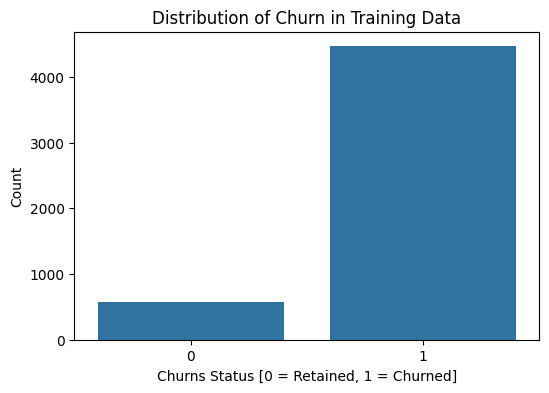

In [46]:
# Visualising the distribution of target variable

plt.figure(figsize = (6,4))
sns.countplot(x = y_train)
plt.title('Distribution of Churn in Training Data')
plt.xlabel('Churns Status [0 = Retained, 1 = Churned]')
plt.ylabel('Count')
;

<Figure size 600x400 with 0 Axes>

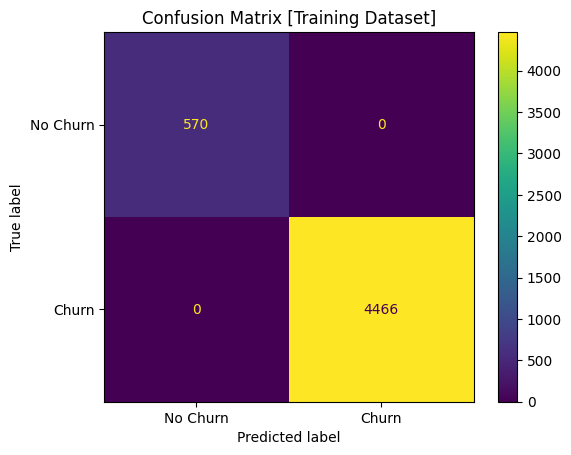

''

In [119]:
# Confusion Matrix

plt.figure(figsize = (6,4))

ConfusionMatrixDisplay.from_estimator(model, x_train, y_train, display_labels = ['No Churn','Churn'])
plt.title('Confusion Matrix [Training Dataset]')
plt.show()
;

#### Random Forest

In [35]:
model = RandomForestClassifier(random_state = 42)

model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [71]:
# Predicting the Probability of churn based of the RFC Model built earlier on entire dataset

df['Churn Probability'] = model.predict_proba(x_input)[:, 1]

df['Churn Probability'].value_counts()

Churn Probability
1.00    5411
0.00     537
0.01     139
0.99     116
0.02      31
0.98      23
0.03      10
0.97       7
0.95       5
0.96       3
0.89       2
0.05       1
0.81       1
0.90       1
0.09       1
0.13       1
0.83       1
0.94       1
0.92       1
0.06       1
0.79       1
0.82       1
Name: count, dtype: int64

Text(0, 0.5, 'Customer Count')

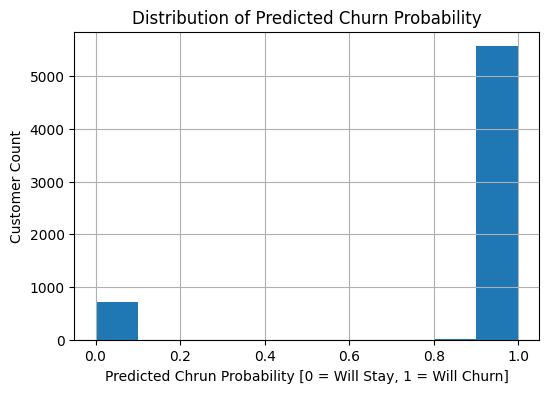

In [116]:
# Churn Probability Histogram

plt.figure(figsize = (6,4))

df['Churn Probability'].hist(bins = 10)
plt.title('Distribution of Predicted Churn Probability')
plt.xlabel('Predicted Chrun Probability [0 = Will Stay, 1 = Will Churn]')
plt.ylabel('Customer Count')

In [76]:
# Predicting test data based on trained data

y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       151
           1       1.00      1.00      1.00      1108

    accuracy                           1.00      1259
   macro avg       1.00      1.00      1.00      1259
weighted avg       1.00      1.00      1.00      1259



#### KMeans

In [60]:
# Using KMeans to insert segmentation into df where customers get grouped into segments

kmeans = KMeans(n_clusters = 4, random_state = 42)

kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [92]:
df['Segment'] = kmeans.fit_predict(df[['Recency', 'Frequency', 'Monetary']])

df['Segment'].value_counts()

# Here segments would imply
# Segment 0 -- VIP
# Segment 1 -- At Risk
# Segment 2 -- Occasional
# Segment 3 -- New Customers

Segment
3    2069
1    1672
0    1441
2    1113
Name: count, dtype: int64

''

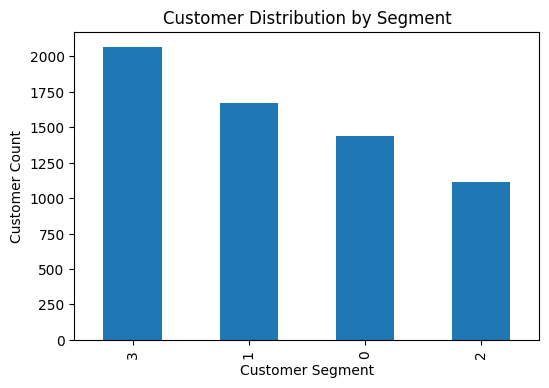

In [115]:
# Segment Count Barplot

plt.figure(figsize = (6,4))

df['Segment'].value_counts().plot.bar()
plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Customer Count')
;

In [80]:
# Segement Data Visual for intepreting clusters

df.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

,Recency,Frequency,Monetary
Segment,,,
0,649.08,1.38,110.91
1,383.66,1.67,134.56
2,941.75,1.13,89.26
3,129.22,1.91,157.43


''

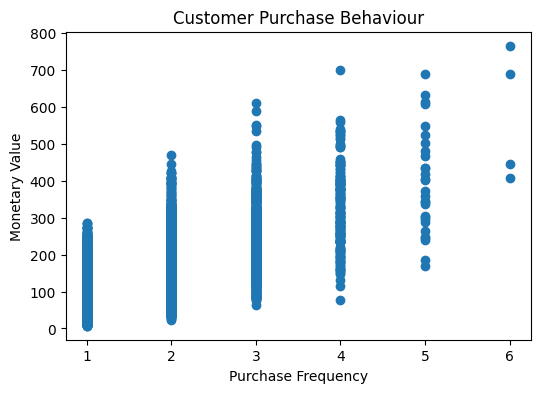

In [118]:
# Frequency Vs Monetary Scatter

plt.figure(figsize = (6,4))

plt.scatter(df['Frequency'], df['Monetary'])
plt.title('Customer Purchase Behaviour')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
;

### LTV (Lifetime Value) Model

In [124]:
# Using LTV to predict Average Order Value

x_ltv = df[['Recency', 'Frequency']]
y_ltv = df['Total_Revenue']

model_ltv = RandomForestRegressor(random_state = 42)

model_ltv.fit(x_ltv, y_ltv)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [130]:
# Generating Predicted LTV and storing in Predicted_LTV Column

df['Predicted_LTV'] = model_ltv.predict(x_ltv)

df['Predicted_LTV'].head()

0    191.312657
1    131.171935
2    106.211319
3     74.356291
4     84.619600
Name: Predicted_LTV, dtype: float64

''

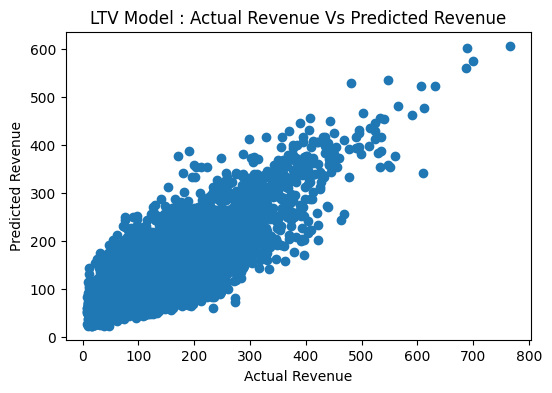

In [132]:
# Plotting Predicted_LTV as Scatter Plot

plt.figure(figsize = (6,4))

plt.scatter(df['Total_Revenue'], df['Predicted_LTV'])

plt.title('LTV Model : Actual Revenue Vs Predicted Revenue')
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
;

### Exporting the dataframe into CSV file to be used in Power BI

In [133]:
df.to_csv('customer_scored_dataset.csv', index = False)